<h1>Deep learning project</h1>
<h1>Mohammad Mahdi Bideh - 99112004</h1>
<h2>LCA-Net: Light Convolutional Autoencoder for Image Dehazing</h2>
<h3>این مقاله راجع به یک مدل کانولوشنال آتوانکودر میباشد که ویژگی های مدل در مقاله ذکر شده و  در کد های این گزارش پیاده سازی شده است.</h3>
<h2>Dataset: RESIDE-Standard</h2>
<h3>به دلیل کمبود منابع سخت افزاری، از تمام داده ها استفاده نشده و به دلیل مشکل سایت آپلود شده (باکس) که نمیشود بخشی از داده ها را به طور جدا دانلود کرد، از بخشی از همین دیتاست که در سایت کگل آپلود شده بود استفاده شده است</h3>

<h2>Functions:</h2>
<h2>General Functions:</h2>
<h3>Import libreries for functions</h3>

In [1]:
import numpy as np
import os
from os.path import join
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt

from PIL import Image

<h3>Define Functions</h3>
<h3>ابتدا توابع مورد نیاز را پیاده سازی کرده، در زیر توضیح ورودی و عملیات تک تک توابع آمده است</h3>
<h3>image_float_to_uint: تبدیل ساختار عکس هایی که بین 0 و 1 هستند به 0 تا 255 که قابل ذخیره سازی در فایل شوند</h3>
<h3>image_uint_to_float: تبدیل ساختار عکس هایی که بین 0 تا 255 هستند به 0 و 1 که یک نوع نرمال سازی هم حساب میشود، برای دادن به عنوان ورودی مدل</h3>
<h3>get_all_img: با دریافت آدرس یک فولدر، تمام عکس های داخل آن فولدر را میخواند و در یک آرایه به عنوان خروجی بر میگرداند</h3>
<h3>plot_before_after: با در یافت دو عکس، دو عکس را در کنار هم به صورت قبل و بعد چاپ میکند، اگر ورودی اسم فایل خالی باشد، صرفا نمایش میدهد ولی اگر پر باشد با آن نام نمودار رسم شده را در فایل ذخیره میکند</h3>
<h3>img_resize: با دریافت آرایه یک عکس و سایز جدید آن، آن عکس را به کمک توابع کتابخانه ای سایزش را عوض میکند که مناسب برای ورودی دادن به مدل شوند، به عنوان مثال در این دیتاست</h3>
<h3>(620, 460 , 3) -> (512, 512, 3)</h3>
<h3>resize_all_img: با دریافت آدرس یک فولدر و سایز جدید برای عکس های آن فولدر، تمام عکس های داخل آن فولدر را به سایز جدید تبدیل میکند و در یک فولدر دیگر با نامی مرتبط در کنار آن عکس های جدید را ذخیره میکند</h3>

In [2]:
def image_float_to_uint(image):
    if np.max(image) < 1:  # image between [0, 1]
        return (image * 255).astype(np.uint8)
    else:  # image between [0, 255]
        return image.astype(np.uint8)


def image_uint_to_float(image):
    if np.max(image) < 1:  # image between [0, 1]
        return image
    else:
        return (image / 255).astype(np.float)


def get_all_img(directory):
    images = sorted(os.listdir(os.path.join(directory)))  # os.listdir gives a list of all files name in this path
    data = []
    for image in images:
        data.append(mpimg.imread(os.path.join(directory, image)))
    return np.array(data)


def plot_before_after(before, after, file_name=""):
    plt.figure(figsize=(15, 5))  # Size of figure (all plot)

    plt.subplot(1, 2, 1)  # (nrows, ncols, index)
    plt.axis('off')
    plt.title("Before", fontsize=20)
    plt.imshow(before)

    plt.subplot(1, 2, 2)
    plt.axis('off')
    plt.title("After", fontsize=20)
    plt.imshow(after)

    if not file_name == "":
        plt.savefig(file_name, bbox_inches='tight')
    plt.show()


def img_resize(img_array, new_size):
    # Convert Image to array with np.array(Image) & convert np.array to Image with Image.fromarray(array)
    return np.array(Image.fromarray(img_array).resize(new_size))


def resize_all_img(directory, new_shape):
    # Creat new folder
    folder_name = directory[- directory[::-1].index('\\'):]
    new_folder_name = folder_name + str(new_shape)
    new_path = os.path.join(directory[:-len(folder_name)], new_folder_name)
    Path(new_path).mkdir(parents=True, exist_ok=True)

    # Resize images and save new image
    images = sorted(os.listdir(os.path.join(directory)))  # os.listdir gives a list of all files name in this path
    for name in images:
        image = Image.open(os.path.join(directory, name))
        image = image.resize(new_shape)
        image.save(os.path.join(new_path, str(name)))

    print("Image resizing completed")

<h2>Dataset Functions</h2>
<h3>توابع زیر، توابعی هستند با خواندن مقاله دیتاست پیاده سازی شده اند</h3>
<h3>در دیتاست مورد بحث، تصاویر مه آلود به صورت مصنوعی با کمک تابع زیر ساخته شده اند</h3>
<h3>I (x) = J (x) t (x) + A(1 - t (x))</h3>
<h3>I(x) = Hazy image, J(x) = Haze-free, A = global atmospheric light, t(x) = transmission matrix</h3>
<h3>x: متغیری دو بعدی که به ازای هر پیکسل این فرمول اعمال میشود</h3>
<h3>که در فرمول بالا تابع تبدیل (تابع تی) به صورت زیر بدست می آید:</h3>
<h3>t (x) = e^(-beta * d(x))</h3>
<h3>که در فرمول بالا تابع دی، تابع فاصله دوربین از اشیا است</h3>
<h3>RGBD: برای ساخت تابع دی به تصاویری به چنین فرمتی که فاکتور عمق دارند، نیاز است</h3>
<h3>NYU Depth Dataset V2: دیتاست مورد بحث از این دیتاست استخراج شده است، زیرا عمق دارد و میتوان با آن تابع دی را تعریف کرد</h3>
<h3>make_trans: با کمک تابع فاصله و یک هایپر پارامتر دلخواه بتا میتوان یک تدبیل تی ساخت</h3>
<h3>haze_trans: با دریافت عکس تمیز (بدون مه) و تبدیل تی و یک هایپر پارامتر که دلخواه است تصویر مه مصنوعی تولید میکند</h3>

In [3]:
# Create a fog mask
def make_trans(d, beta):
    # t (x) = e^(-beta * d(x))
    # beta = scattering coefficient, d(x) = distance between the object and the camera
    t = np.zeros(d.shape)
    for row_n, row in enumerate(d):
        for x_n, x in enumerate(row):
            t[row_n, x_n] = np.e ** (-beta * x)
    return t


# Make synthetic foggy image
def haze_trans(J, t, A):
    # I (x) = J (x) t (x) + A(1 - t (x))    x = 2d matrix
    # I(x) = Hazy image, J(x) = Haze-free, A = global atmospheric light, t(x) = transmission matrix
    I = np.zeros(J.shape)
    for row_n, row in enumerate(J):
        for pixel_n, pixel in enumerate(row):
            for rgb_n, rgb in enumerate(pixel):
                I[row_n, pixel_n, rgb_n] = rgb * t[row_n, pixel_n] + A * (1 - t[row_n, pixel_n])
                # print(I[row_n, pixel_n, rgb_n])
    return np.array(I)


<h3>به عنوان نمونه، از توابع بالا استفاده کرده و نتایجش در کد پایین آمده</h3>
<h3>ساخت یک تابع تبدیل ساده</h3>

d.shape =  (9, 4)


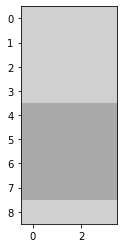

In [16]:
# Create sample mask
d = np.array([[1, 1, 1, 1],
              [1, 1, 1, 1],
              [1, 1, 1, 1],
              [1, 1, 1, 1],
              [2, 2, 2, 2],
              [2, 2, 2, 2],
              [2, 2, 2, 2],
              [2, 2, 2, 2],
              [1, 1, 1, 1]])

# d = d * 0.1

print("d.shape = ", d.shape)

sample_t = make_trans(d, 0.2)
img_sample_t = image_float_to_uint(sample_t)
plt.imshow(img_sample_t, cmap='gray', vmin=0, vmax=255)
plt.show()

<h3>ساخت یک تصویر مه آلود مصنوعی به کمک تابع بالا</h3>

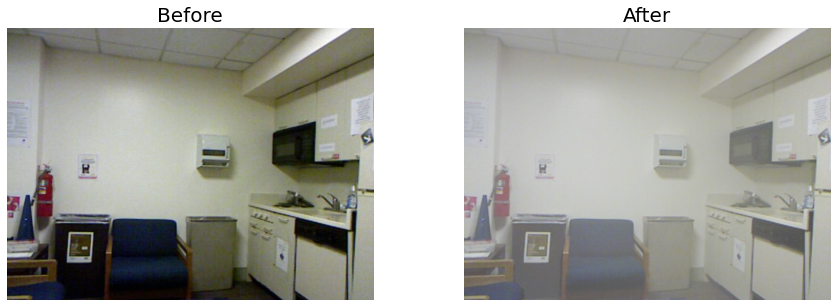

In [20]:
# Create dataset with mask and clear image
dataset_path = './Dataset/RESIDE/ITS'

# shape: (?, ?, 3)
img = mpimg.imread(join(dataset_path, 'Clear/1.png'))
t_img = mpimg.imread(join(dataset_path, 'Trans/1_1.png'))

# convert to NumPy array
img_array = np.array(img)
t = np.array(t_img)

haze_img = haze_trans(img_array, t, 0.8)

plot_before_after(img_array, haze_img)

<h2>Resize all images in dataset</h2>
<h3>برای استفاده از تصویر در مدل، باید ابعاد تصاویر دیتاست را عوض کرد، بعد از این عملیات دیتاست نرمالایز شده و مناسب برای استفاده توسط مدل مقاله است</h3>

In [21]:
org_image_shape = (460, 620)
image_shape = (512, 512)

# Resize all image in directory to new shape
resize_all_img(join(dataset_path, 'Clear'), image_shape)
resize_all_img(join(dataset_path, 'Haze'), image_shape)

Image resizing completed
Image resizing completed


<h2>LCA-Net</h2>
<h3>Import libreries</h3>

In [22]:
from keras.models import Sequential
from keras import Input
from keras.layers import Dense
from keras.layers import Conv2D, AveragePooling2D, UpSampling2D
from keras.optimizers import Adam

<h3>Define & compile and build model</h3>
<h3>مدل آتوانکودر طبق گفته های بخش به بخش مقاله پیاده سازی شده است</h3>

In [23]:
# Create Autoencoder
def LCA_Net(image_size, gray=False):
    kernel_size = 3  # (3, 3)
    pooling_size = 2  # (2, 2)

    image_shape = np.concatenate((image_size, [1] if gray else [3]))

    model = Sequential()

    # Input layer
    model.add(Input(shape=image_shape))

    #########
    # Encoder
    # Conv
    model.add(Conv2D(50, kernel_size=kernel_size, activation='relu', padding='same'))
    model.add(AveragePooling2D(pooling_size, padding='same'))
    model.add(Conv2D(50, kernel_size=kernel_size, activation='relu', padding='same'))
    model.add(AveragePooling2D(pooling_size, padding='same'))
    # Dense
    model.add(Dense(10))

    # Decoder
    # Dense
    model.add(Dense(10))
    # Conv
    model.add(Conv2D(50, kernel_size=kernel_size, activation='relu', padding='same'))
    model.add(UpSampling2D(pooling_size))
    model.add(Conv2D(50, kernel_size=kernel_size, activation='relu', padding='same'))
    model.add(UpSampling2D(pooling_size))

    # Output layer
    # model.add(Conv2D(3, kernel_size=kernel_size, activation='sigmoid', padding='same'))
    model.add(Conv2D(3, kernel_size=kernel_size, activation='relu', padding='same'))

    # Compile & build model
    opt = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)   # this settings are default
    model.compile(optimizer=opt, loss='mse')
    # model.compile(optimizer='adam', loss='binary_crossentropy')
    model.build()

    model.summary()

    return model

<h3>ساختار آتوانکدر مقاله</h3>

![title](img/model.png)

<h2>Main</h2>
<h3>حال داده ها را میخوانیم و بخش باقی مانده پیش پردازش را انجام میدهیم</h3>
<h3>تنها پیش پردازش باقی مانده 10 برابر کردن خروجی ها (عکس های تمیز) است، زیرا به ازای هر عکس بدون مه، 10 عکس مه مصنوعی داریم</h3>

In [24]:
# X.shape = (90, ?, ?, 3)
# X & y are Normalized ([0, 1])
X = get_all_img(join(dataset_path, 'Haze(512, 512)'))
y = get_all_img(join(dataset_path, 'Clear(512, 512)'))

# Multiple array elements (one y has 10 X!)
y = np.repeat(y, 10, axis=0)

<h3>داده ها نرمالایز شده اند</h3>

In [25]:
print(X[0])

[[[0.7137255  0.6784314  0.6784314 ]
  [0.70980394 0.6784314  0.6784314 ]
  [0.70980394 0.6745098  0.6745098 ]
  ...
  [0.79607844 0.69803923 0.8039216 ]
  [0.78039217 0.6745098  0.78431374]
  [0.7607843  0.64705884 0.7607843 ]]

 [[0.7176471  0.68235296 0.6784314 ]
  [0.7176471  0.68235296 0.68235296]
  [0.7137255  0.6784314  0.6784314 ]
  ...
  [0.93333334 0.90588236 0.8862745 ]
  [0.92156863 0.8901961  0.87058824]
  [0.92156863 0.8901961  0.8745098 ]]

 [[0.72156864 0.6862745  0.68235296]
  [0.72156864 0.68235296 0.68235296]
  [0.7176471  0.6784314  0.68235296]
  ...
  [0.9529412  0.9607843  0.9019608 ]
  [0.9529412  0.9607843  0.89411765]
  [0.9607843  0.9607843  0.8980392 ]]

 ...

 [[0.6627451  0.6039216  0.59607846]
  [0.6627451  0.6        0.59607846]
  [0.6627451  0.59607846 0.59607846]
  ...
  [0.7058824  0.67058825 0.6784314 ]
  [0.627451   0.5647059  0.5764706 ]
  [0.45490196 0.35686275 0.3764706 ]]

 [[0.6627451  0.6        0.59607846]
  [0.65882355 0.59607846 0.59607846]


<h3>Build model</h3>

In [26]:
# Build LCA_Net Model
model = LCA_Net(image_shape)

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 512, 512, 50)      1400      
_________________________________________________________________
average_pooling2d (AveragePo (None, 256, 256, 50)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 256, 256, 50)      22550     
_________________________________________________________________
average_pooling2d_1 (Average (None, 128, 128, 50)      0         
_________________________________________________________________
dense (Dense)                (None, 128, 128, 10)      510       
_________________________________________________________________
dense_1 (Dense)              (None, 128, 128, 10)      110       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 128, 128, 50)      4

<h3>Train model</h3>
<h3>به دلیل اینکه ژوپیتر با جی پی یو کار نمیکند، به کمک پایچرم مدل را آموزش داده و وزن هارا انتقال داده و لود کرده</h3>

<h3>Epoch 1/5</h3>
<h3>125/125 [==============================] - 740s 6s/step - loss: 0.0782</h3>
<h3>Epoch 2/5</h3>
<h3>125/125 [==============================] - 710s 6s/step - loss: 0.0731</h3>
<h3>Epoch 3/5</h3>
<h3>125/125 [==============================] - 710s 6s/step - loss: 0.0723</h3>
<h3>Epoch 4/5</h3>
<h3>125/125 [==============================] - 710s 6s/step - loss: 0.0722</h3>
<h3>Epoch 5/5</h3>
<h3>125/125 [==============================] - 710s 6s/step - loss: 0.0720</h3>
<h3>Saved model to disk</h3>
<h2>Load model wights from file</h2>

In [2]:
from keras.models import model_from_json

In [3]:
# model.fit(X, y, batch_size=64, epochs=5, verbose=1)
# load json and create model
json_file = open('model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("model.h5")
print("Loaded model from disk")

Loaded model from disk


In [9]:
image_shape = (512, 512)

<h3>Load and resize image for test</h3>
<h3>برای تست مدل، از عکس هایی از دیتاست که از مه واقعی گرفته شده اند استفاده میکنیم</h3>

In [33]:
# Load an image for test
test = image_float_to_uint(mpimg.imread("./Dataset/RESIDE/HSTS/real-world/HazyDr_Google_396.jpeg"))
# test = image_float_to_uint(mpimg.imread("./Dataset/RESIDE/ITS/Haze(512, 512)/1_1_0.90179.png"))

# Resize image & convert [0, 255] to [0, 1] (Normalize)
test_resized = image_uint_to_float(img_resize(test, image_shape))

<ipython-input-5-7f14040e87b0>:12: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  return (image / 255).astype(np.float)


<h3>ساختار تک عکس ورودی را درست کرده و به مدل داده تا خروجی را بگیریم</h3>

In [34]:
# Reshape a sample to normal form (1, ?, ?, 3)
test_reshaped = test_resized.reshape(np.concatenate(([1], image_shape, [3])))

# Predict foggy image (Fog removal)
X_pred = loaded_model.predict(test_reshaped)

<h2>Defogging example</h2>
<h3>قبل و بعد (حذف مه به وسیله مدل آتوانکودر) به نمایش در آورده</h3>

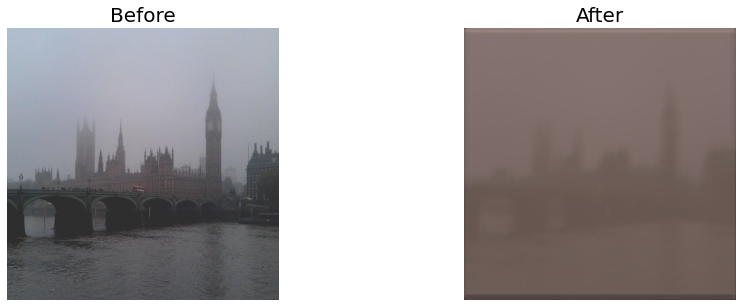

In [35]:
plot_before_after(test_reshaped[0], X_pred[0])